In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## Read Dataset and display the first 5 rows

In [2]:
data=pd.read_csv("C:/Users/alamia/Desktop/Bengaluru_House_Data.csv")
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## Data Preprocessing

In [3]:
print(data.duplicated().sum())

529


In [4]:
data.drop_duplicates(inplace=True)
print(data.duplicated().sum())

0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12791 non-null  object 
 1   availability  12791 non-null  object 
 2   location      12790 non-null  object 
 3   size          12775 non-null  object 
 4   society       7463 non-null   object 
 5   total_sqft    12791 non-null  object 
 6   bath          12718 non-null  float64
 7   balcony       12186 non-null  float64
 8   price         12791 non-null  float64
dtypes: float64(3), object(6)
memory usage: 999.3+ KB


In [6]:
def convert_sqft(x):
    try:
        if '-' in str(x):
            a,b = x.split('-')
            return (float(a) + float(b))/2
        return float(x)
    except:
        return None

In [7]:
data['total_sqft']=data['total_sqft'].apply(convert_sqft)

In [8]:
def convert_size(x):
    try:
        return int(str(x).split(' ')[0])
    except:
        return None

In [9]:
data['size']=data['size'].apply(convert_size)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12791 non-null  object 
 1   availability  12791 non-null  object 
 2   location      12790 non-null  object 
 3   size          12775 non-null  float64
 4   society       7463 non-null   object 
 5   total_sqft    12745 non-null  float64
 6   bath          12718 non-null  float64
 7   balcony       12186 non-null  float64
 8   price         12791 non-null  float64
dtypes: float64(5), object(4)
memory usage: 999.3+ KB


In [11]:
print(data.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5328
total_sqft        46
bath              73
balcony          605
price              0
dtype: int64


In [12]:
#remove missing value in location  & size columns
data.dropna(subset=['location','size','total_sqft'],inplace=True)

#remove society column 
data.drop("society", axis=1,errors='ignore', inplace=True)

#fill missing values in bath column with median
data['bath']=data['bath'].fillna(data['bath'].median())

# fill missing values in balcony column with mode
data['balcony']=data['balcony'].fillna(data['balcony'].mode()[0])

In [13]:
print(data.isnull().sum())

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64


In [14]:
data.describe()

,size,total_sqft,bath,balcony,price
count,12728.000000,12728.000000,12728.00000,12728.000000,12728.000000
mean,2.816782,1568.765510,2.70396,1.602766,114.228781
std,1.308978,1259.945431,1.35301,0.807639,151.617682
min,1.000000,1.000000,1.00000,0.000000,8.000000
25%,2.000000,1100.000000,2.00000,1.000000,50.000000
50%,3.000000,1280.000000,2.00000,2.000000,73.000000
75%,3.000000,1690.000000,3.00000,2.000000,120.000000
max,43.000000,52272.000000,40.00000,3.000000,3600.000000


In [15]:
data.sample(5)

,area_type,availability,location,size,total_sqft,bath,balcony,price
5869,Super built-up Area,18-Apr,Thanisandra,2.0,1250.0,1.0,1.0,54.000
11622,Super built-up Area,Ready To Move,Anantapuram,3.0,1495.0,2.0,1.0,63.000
5382,Super built-up Area,19-Dec,Whitefield,1.0,709.0,1.0,0.0,34.735
4733,Super built-up Area,19-Dec,Hebbal,3.0,1255.0,3.0,2.0,77.680
4446,Plot Area,Ready To Move,Old Town,8.0,750.0,8.0,2.0,200.000


In [16]:
data = data[data['bath'] < 10]
data = data[data['size'] < 20]
data = data[data['total_sqft'] > 300]

## Boxplot before remove outliers

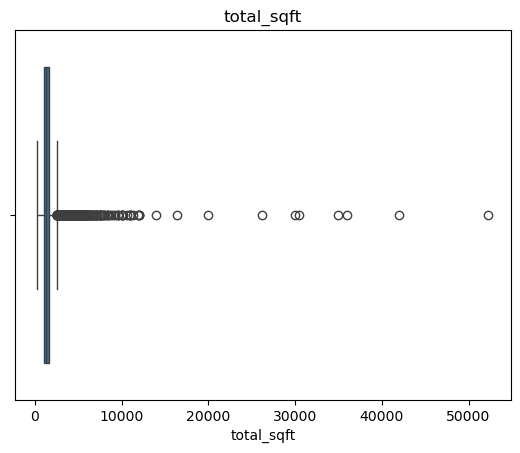

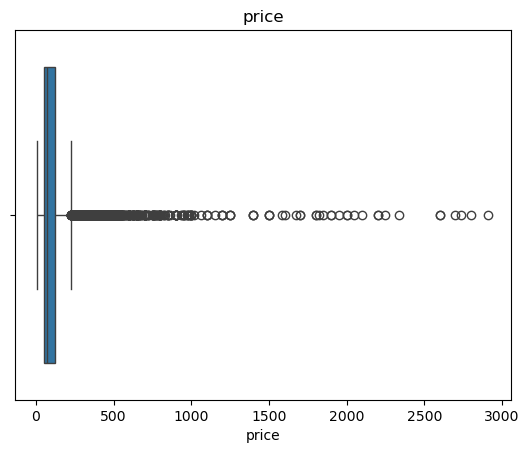

In [17]:
cols = ['total_sqft', 'price']

for col in cols:
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [18]:
#remove outliers from price column 
Q1=data["price"].quantile(.25)
Q3=data["price"].quantile(.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
data=data[(data["price"]<= upper ) & (data["price"]>= lower)]


#remove outliers from total_sqft column 
Q1=data["total_sqft"].quantile(.25)
Q3=data["total_sqft"].quantile(.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
data=data[(data["total_sqft"]<= upper ) & (data["total_sqft"]>= lower)]

## Boxplot After Remove Outliers

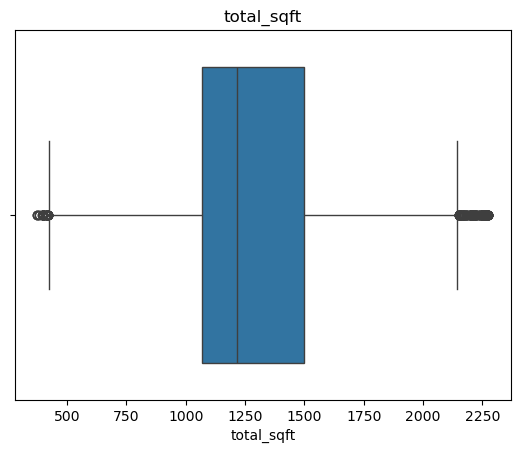

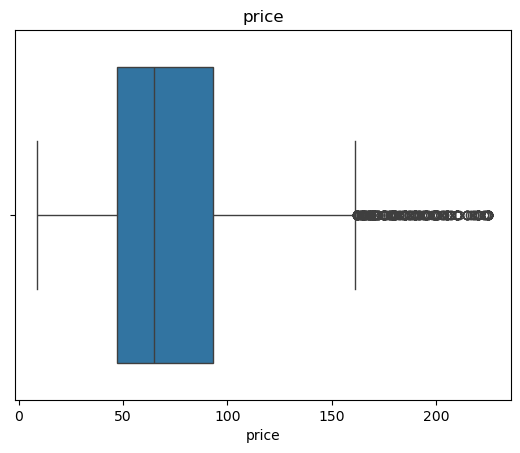

In [19]:
cols = ['total_sqft', 'price']

for col in cols:
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

## Deal With Location column 

In [20]:
location_counts = data['location'].value_counts()

data['location'] = data['location'].apply(lambda x: x if location_counts[x] > 50 else 'other')

In [21]:
data['location'].nunique()

38

In [22]:
data = pd.get_dummies(data, columns=['location'], drop_first=True)

## Deal With area_type column

In [23]:
data = pd.get_dummies(data, columns=['area_type'], drop_first=True)

## Deal with availability column

In [24]:
data['availability'].nunique()

80

In [25]:
data['ready_to_move'] = data['availability'].apply(
    lambda x: 1 if x == 'Ready To Move' else 0
)

In [26]:
data.drop('availability', axis=1, inplace=True)

In [27]:
data.sample(1)

,size,total_sqft,bath,balcony,price,location_Akshaya Nagar,location_Banashankari,location_Bannerghatta Road,location_Begur Road,location_Bellandur,...,location_Uttarahalli,location_Varthur,location_Whitefield,location_Yelahanka,location_Yeshwanthpur,location_other,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,ready_to_move
10772,2.0,935.0,2.0,3.0,45.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,1


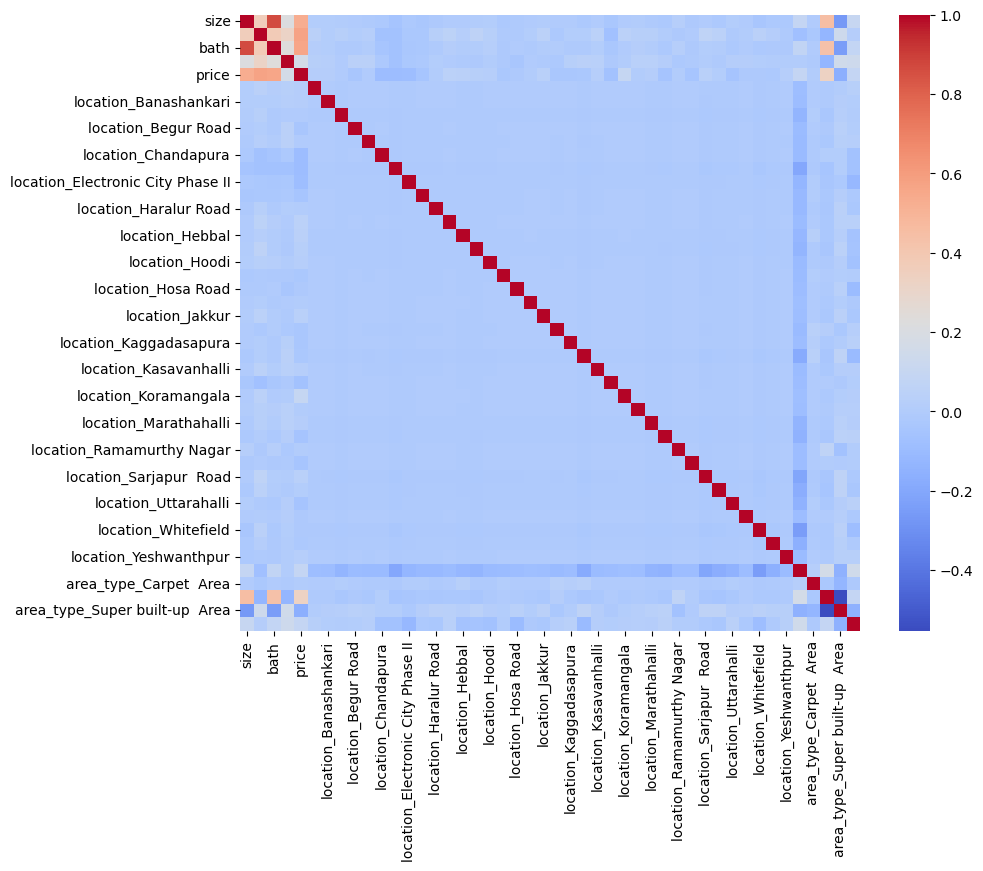

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.show()

In [29]:
data.corr()['price'].sort_values(ascending=False)

price                                1.000000
total_sqft                           0.575067
bath                                 0.559111
size                                 0.528568
area_type_Plot  Area                 0.331560
balcony                              0.163766
location_Koramangala                 0.091373
ready_to_move                        0.086842
location_other                       0.086156
location_Harlur                      0.044347
location_Hebbal                      0.038611
location_Jakkur                      0.032835
location_Sarjapur  Road              0.032722
location_Hennur Road                 0.027065
location_Hoodi                       0.022194
location_Kasavanhalli                0.019459
location_Yeshwanthpur                0.017408
location_Akshaya Nagar               0.017211
location_Marathahalli                0.013387
location_Banashankari                0.013158
location_Thanisandra                 0.008230
location_Haralur Road             

In [30]:
corr = data.corr()['price'].sort_values(ascending=False)

corr[abs(corr) > 0.1]

price                             1.000000
total_sqft                        0.575067
bath                              0.559111
size                              0.528568
area_type_Plot  Area              0.331560
balcony                           0.163766
area_type_Super built-up  Area   -0.170335
Name: price, dtype: float64

In [31]:
data['price_per_sqft'] = data['price'] / data['total_sqft']
mean = data['price_per_sqft'].mean()
std = data['price_per_sqft'].std()

data = data[(data['price_per_sqft'] > mean - std) & 
            (data['price_per_sqft'] < mean + std)]

data.drop('price_per_sqft', axis=1, inplace=True)

In [32]:
x=data.drop('price',axis=1)
y=data['price']

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [34]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Apply linear regression model

In [35]:
model=LinearRegression()
model.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
y_pred = model.predict(x_test_scaled)

In [37]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.680941194087346
MAE: 12.961852755900365


## Apply Random forest

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500, random_state=42)

In [39]:
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)

In [40]:
print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2: 0.7069086074525609
MAE: 11.794917815336886


In [41]:
x.columns

Index(['size', 'total_sqft', 'bath', 'balcony', 'location_Akshaya Nagar',
       'location_Banashankari', 'location_Bannerghatta Road',
       'location_Begur Road', 'location_Bellandur', 'location_Chandapura',
       'location_Electronic City', 'location_Electronic City Phase II',
       'location_Electronics City Phase 1', 'location_Haralur Road',
       'location_Harlur', 'location_Hebbal', 'location_Hennur Road',
       'location_Hoodi', 'location_Hormavu', 'location_Hosa Road',
       'location_JP Nagar', 'location_Jakkur', 'location_KR Puram',
       'location_Kaggadasapura', 'location_Kanakpura Road',
       'location_Kasavanhalli', 'location_Kengeri', 'location_Koramangala',
       'location_Kothanur', 'location_Marathahalli',
       'location_Raja Rajeshwari Nagar', 'location_Ramamurthy Nagar',
       'location_Sarjapur', 'location_Sarjapur  Road', 'location_Thanisandra',
       'location_Uttarahalli', 'location_Varthur', 'location_Whitefield',
       'location_Yelahanka', 'lo

In [42]:
new_data = {
    'size': 2,
    'total_sqft': 1200,
    'bath': 2,
    'balcony': 1,
    'ready_to_move': 1,

    # area type
    'area_type_Super built-up Area': 1,

    # location
    'location_Whitefield': 1
}

In [ ]:
import pandas as pd

new_df = pd.DataFrame([new_data])

new_df = new_df.reindex(columns=x.columns, fill_value=0)

In [44]:
prediction = rf.predict(new_df)

print("Predicted Price:", prediction[0])

Predicted Price: 51.925281402708386
